In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import numpy as np
from numpy import sin, cos, pi
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse, root_mean_squared_error as rmse

In [2]:
def analytical(theta:float,beta:float,alpha:float):
    return (\
        cos(alpha)**4 + sin(alpha)**4 +\
        2 * (sin(alpha)**2) * (cos(alpha)**2) * cos(theta) + \
        cos(alpha+beta)**4 + sin(alpha+beta)**4 + \
        2 * (sin(alpha+beta)**2) * (cos(alpha+beta)**2) * cos(theta)\
        )/2

In [3]:
def plot_surface_from_csv(array1,array2):
        fig = go.Figure()
        fig.add_trace(go.Surface(
            z=array1, 
            colorscale='Emrld',
            opacity=.8,
            name='Model',
            colorbar=dict(title='Theoretical', x=0.9)
        ))
        
    
        fig.add_trace(go.Surface(
            z=array2, 
            #colorscale='Reds',
            opacity=0.8, # Transparency helps see where they intersect
            name='Experimental',
            colorbar=dict(title='Experimental', x=1.05)
        ))
        # Customize the layout for better visualization
        fig.update_layout(
            title='3D Surface Plot from CSV',
            autosize=False,
            width=800,
            height=800,
            margin=dict(l=65, r=50, b=65, t=90),
            scene=dict(
                xaxis_title='X Axis',
                yaxis_title='Y Axis',
                zaxis_title='Z Axis'
            ),
            # --- NUEVO: Aumentar tamaño de fuente ---
            font=dict(size=16) 
        )
        
        # Display the plot
        fig.show()


In [4]:
reviewed_probability_filenames = pd.read_csv("./runs/filenames.csv",header=None).dropna(axis=1,how='all').values.flatten()
#reviewed_probability_filenames

In [5]:
noisy_probability_filenames = pd.read_csv("./runs/noisy_filenames.csv",header=None).dropna(axis=1,how='all').values.flatten()
#noisy_probability_filenames

In [6]:
N_data=20

theta_FSS = np.linspace(0,2*pi,N_data)
beta_angle = np.linspace(0,pi,N_data)
alpha = pi/16

path = './runs/'
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

noiseless_r2 = list()
noiseless_mse = list()
noiseless_rmse = list()

noisy_r2 = list()
noisy_mse = list()
noisy_rmse = list()

model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

for experiment_name in reviewed_probability_filenames:
    experiment = pd.read_csv(path+experiment_name, header=None).dropna(axis=1,how='all').values    
    noiseless_r2.append( 1-r2(y_true=model,y_pred=experiment) )
    noiseless_mse.append( (mse(y_true=model,y_pred=experiment) ))
    noiseless_rmse.append( (rmse(y_true=model,y_pred=experiment) ))

for experiment_name in noisy_probability_filenames:
    experiment = pd.read_csv(path+experiment_name, header=None).dropna(axis=1,how='all').values    
    noisy_r2.append( 1-r2(y_true=model,y_pred=experiment) )
    noisy_mse.append( mse(y_true=model,y_pred=experiment) )
    noisy_rmse.append( rmse(y_true=model,y_pred=experiment) )
"""
N_states = pd.DataFrame(dict(zip(['N_states'],[[1.0E3,5.0E3,1.0E4,1.5E4,2.0E4,2.5E4,3.0E4,3.5E4,4.0E4,4.5E4]])))
df_reviewed = pd.DataFrame( dict(zip(['Noise','R2','RMSE','MSE'],[[0.0 for k in range(len (noiseless_mse))],noiseless_r2,noiseless_rmse,noiseless_mse])) )
df_noisy = pd.DataFrame( dict(zip(['Noise','R2','RMSE','MSE'],[[9.0 for k in range(len(noisy_mse))],noisy_r2,noisy_rmse,noisy_mse])) )
"""
N_states_list = [1.0E3, 5.0E3, 1.0E4, 1.5E4, 2.0E4, 2.5E4, 3.0E4, 3.5E4, 4.0E4, 4.5E4]

df_reviewed = pd.DataFrame({
    'Noise': 0.0,
    'R2': noiseless_r2,
    'RMSE': noiseless_rmse,
    'MSE': noiseless_mse,
    'N_states': N_states_list
})

df_noisy = pd.DataFrame({
    'Noise': 9.0,
    'R2': noisy_r2,
    'RMSE': noisy_rmse,
    'MSE': noisy_mse,
    'N_states': N_states_list
})

# Concatenamos de forma limpia
results = pd.concat([df_reviewed, df_noisy], ignore_index=True)

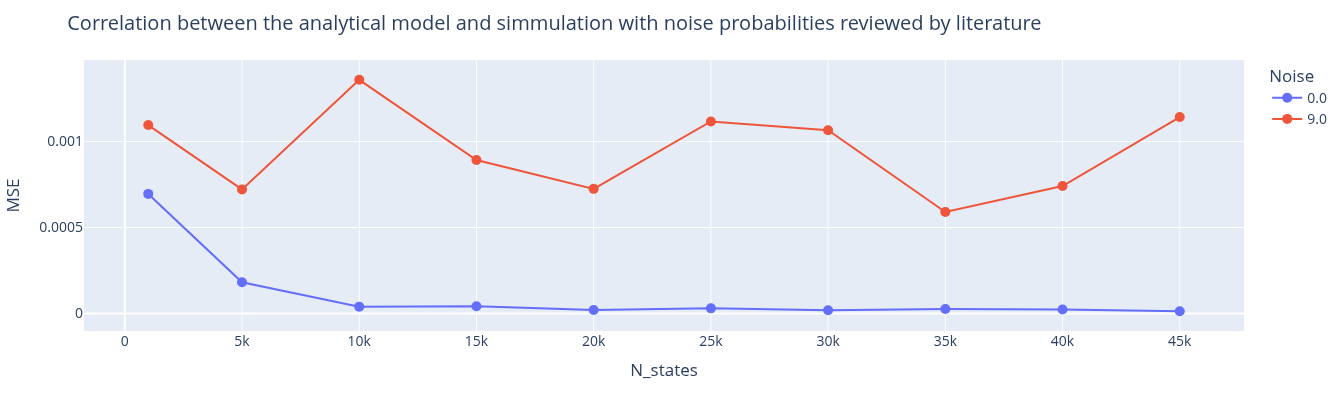

In [7]:
# Configuración del subplot
fig = px.line(results,
              x = 'N_states',
              y = 'MSE',
              color = 'Noise',
              markers = True,
              )

fig.update_traces(marker_size=10)
#fig.update_yaxes(range=[0,0.1])
fig.update_layout(
    title = 'Correlation between the analytical model and simmulation with noise probabilities reviewed by literature',
    height = 411,
    width = 700,
    # --- NUEVO: Aumentar tamaño de fuente ---
    font=dict(size=14)
)

In [8]:
from sklearn.preprocessing import StandardScaler as zscaler

In [9]:
# Create an empty DataFrame with the exact same index as 'results'
scaled_results = pd.DataFrame(index=results.index, columns=['R2 scaled', 'RMSE scaled', 'MSE scaled'])

# Create masks to isolate each experiment
mask_0 = results['Noise'] == 0.0
mask_9 = results['Noise'] == 9.0

# Initialize independent scalers
scaler_0 = zscaler()
scaler_9 = zscaler()

# Fit and transform independently, then assign back
scaled_results.loc[mask_0, ['R2 scaled', 'RMSE scaled', 'MSE scaled']] = scaler_0.fit_transform(results.loc[mask_0, ['R2', 'RMSE', 'MSE']])
scaled_results.loc[mask_9, ['R2 scaled', 'RMSE scaled', 'MSE scaled']] = scaler_9.fit_transform(results.loc[mask_9, ['R2', 'RMSE', 'MSE']])

# Ensure the columns are strictly float types so Plotly handles them correctly
scaled_results = scaled_results.astype(float)

In [10]:
results_df = pd.concat([results, scaled_results], axis=1)
results_df.head()

,Noise,R2,RMSE,MSE,N_states,R2 scaled,RMSE scaled,MSE scaled
0,0.0,0.082469,0.024327,0.000696,1000.0,2.962199,2.772724,2.917231
1,0.0,0.015119,0.012150,0.000182,5000.0,0.109073,0.766359,0.360085
2,0.0,0.006576,0.006111,0.000040,10000.0,-0.252809,-0.228699,-0.344029
3,0.0,0.005322,0.006116,0.000042,15000.0,-0.305967,-0.227755,-0.334086
4,0.0,0.003639,0.004385,0.000020,20000.0,-0.377253,-0.513026,-0.443612


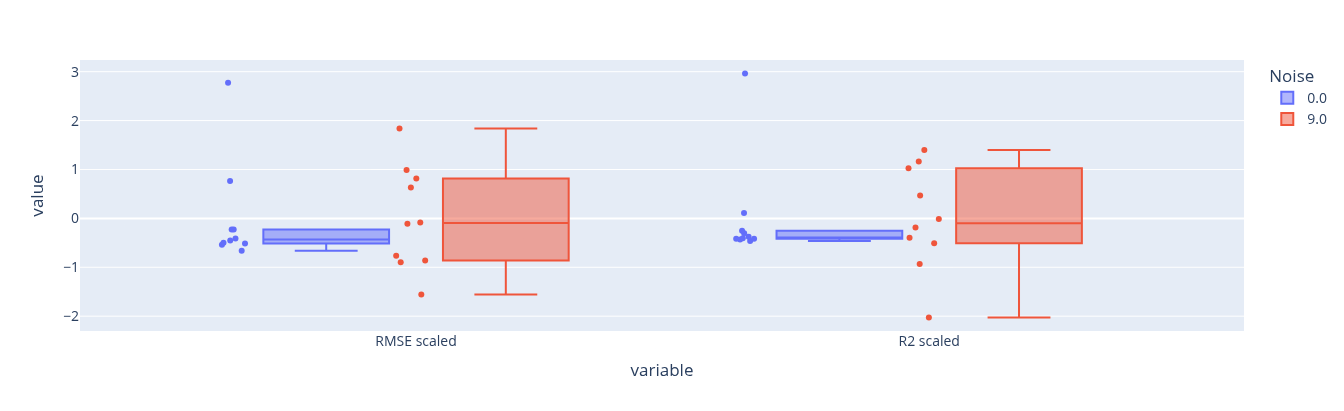

In [11]:
fig = px.box(results_df,
       y = ['RMSE scaled', 'R2 scaled'],
       points='all',
             color='Noise',
       height = 411,
       width = 700
         )
fig.update_layout(font=dict(size=14))
fig.show()

In [12]:
path = 'fixed error results/'


pure_filenames = ['pure_50x50_mesh_1E3_states_E91_data_2026_aer_simulator_25_02_2026_12_56_22',
                  'pure_50x50_mesh_5E3_states_E91_data_2026_aer_simulator_25_02_2026_14_33_00',
                  'pure_50x50_mesh_1E4_states_E91_data_2026_aer_simulator_25_02_2026_20_10_04',
                  'pure_50x50_mesh_1.5E4_states_E91_data_2026_aer_simulator_26_02_2026_15_59_56',
                  'pure_50x50_mesh_2E4_states_E91_data_2026_aer_simulator_25_02_2026_22_54_49']

error_filenames= ['50x50_mesh_1E3_states_E91_data_2026_aer_simulator_23_02_2026_18_32_14',
                  '50x50_mesh_5E3_states_E91_data_2026_aer_simulator_23_02_2026_14_22_55',
                  '50x50_mesh_1E4_estates_E91_data_2026_aer_simulator_23_02_2026_14_36_26',
                  '50x50_mesh_1.5E4_states_E91_data_2026_aer_simulator_23_02_2026_23_12_07',
                  '50x50_mesh_2E4_states_E91_data_2026_aer_simulator_24_02_2026_07_12_29',
                  '50x50_mesh_2.5E4_states_E91_data_2026_aer_simulator_24_02_2026_11_27_03']

test_filenames= ['10x10_mesh_1E3_E91_data_2026_aer_simulator_02_03_2026_15_36_28',
                 '10x10_mesh_1E4_states_E91_data_2026_aer_simulator_02_03_2026_16_23_52',
                 '10x10_mesh_1.5E4_states_E91_data_2026_aer_simulator_02_03_2026_19_08_36',
                 '10x10_mesh_2E4_states_E91_data_2026_aer_simulator_02_03_2026_19_41_56',
                 '10x10_mesh_2.5E4_states_E91_data_2026_aer_simulator_02_03_2026_19_04_56',
                 '10x10_3E4_states_E91_data_2026_aer_simulator_02_03_2026_15_54_44',
                 '10x10_mesh_3.5E4_states_E91_data_2026_aer_simulator_03_03_2026_00_58_08',
                 '10x10_mesh_4E4_states_E91_data_2026_aer_simulator_03_03_2026_00_58_51',]

In [13]:
N_data=20

theta_FSS = np.linspace(0,2*pi,N_data)
beta_angle = np.linspace(0,pi,N_data)
alpha = pi/16

experiment_number = 5
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

#"""

correlation_10_error = list()
correlation_50_error = list()
correlation_50_pure = list()

for experiment_name in test_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1,how='all').values    
    theta_FSS = np.linspace(0,2*pi,10)
    beta_angle = np.linspace(0,pi,10)
    model_10_error = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])
    correlation_10_error.append( rmse(y_true=model_10_error,y_pred=experiment) )
    
for experiment_name in error_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1,how='all').values
    theta_FSS = np.linspace(0,2*pi,50)
    beta_angle = np.linspace(0,pi,50)
    model_50_error = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])
    correlation_50_error.append( rmse(y_true=model_50_error,y_pred=experiment) )
    
for experiment_name in pure_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1,how='all').values
    theta_FSS = np.linspace(0,2*pi,50)
    beta_angle = np.linspace(0,pi,50)
    model_50_pure = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])
    correlation_50_pure.append( rmse(y_true=model_50_pure,y_pred=experiment) )


# Creación de los DataFrames
df_50_pure  = pd.DataFrame( dict(zip(['Nstates','RMSE'],[[1E3,1E4,1.5E4,2E4,2.5E4],correlation_50_pure])) )
df_50_error = pd.DataFrame( dict(zip(['Nstates','RMSE'],[[1E3,5E3,1E4,1.5E4,2E4,2.5E4],correlation_50_error])) )
df_10_error = pd.DataFrame( dict(zip(['Nstates','RMSE'],[[1E3,1E4,1.5E4,2E4,2.5E4,3E4,3.5E4,4E4],correlation_10_error])) )


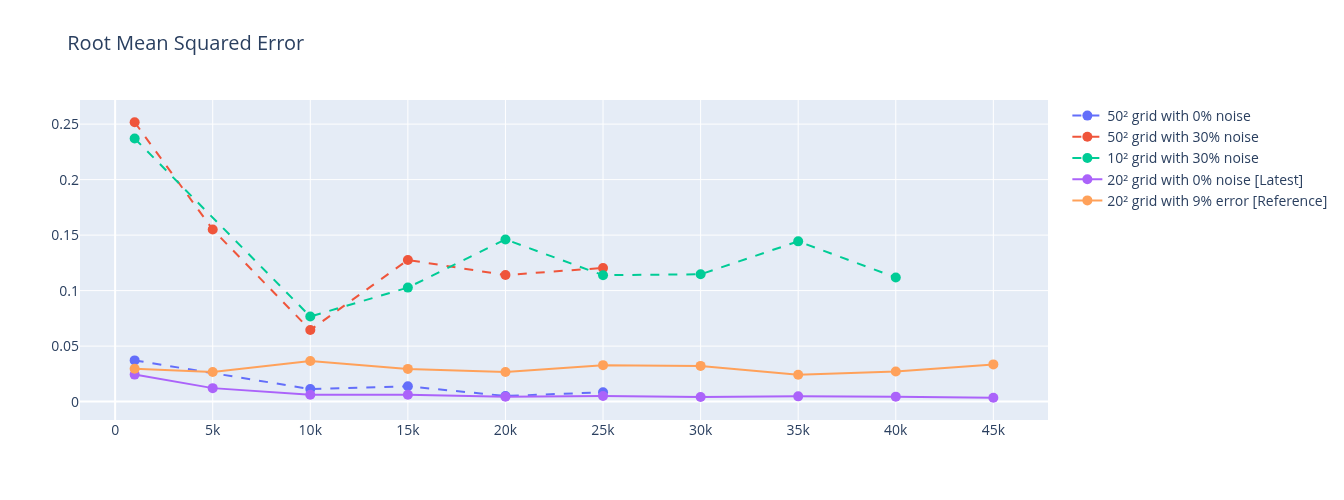

In [14]:
# Configuración del subplot
fig = make_subplots(
    rows=1, 
    cols=1, 
     # Actualizado para que coincida con tus datos
)

# Agregar la primera fila (row=1)
fig.add_trace(
    go.Scatter(
        x=df_50_pure['Nstates'], 
        y=df_50_pure['RMSE'], 
        mode='lines+markers', 
        name='50² grid with 0% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

# Agregar la segunda fila (row=2)
fig.add_trace(
    go.Scatter(
        x=df_50_error['Nstates'], 
        y=df_50_error['RMSE'], 
        mode='lines+markers', 
        name='50² grid with 30% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

# Agregar la tercera fila (row=3)
fig.add_trace(
    go.Scatter(
        x=df_10_error['Nstates'], 
        y=df_10_error['RMSE'], 
        mode='lines+markers', 
        name='10² grid with 30% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)
fig.add_trace(go.Scatter(
    x = results_df.loc[results_df['Noise'] == 0.0, 'N_states'],
    y = results_df.loc[results_df['Noise'] == 0.0, 'RMSE'],
    name="20² grid with 0% noise [Latest]",
    mode='lines+markers'
))

fig.add_trace(go.Scatter(
    x = results_df.loc[results_df['Noise'] == 9.0, 'N_states'],
    y = results_df.loc[results_df['Noise'] == 9.0, 'RMSE'],
    name="20² grid with 9% error [Reference]",
    mode='lines+markers'
))

fig.update_traces(marker_size=10)

fig.update_layout(
    title = 'Correlation between the analytical model and simulation with noise probabilities reviewed by literature<br>Mean Square Error',
    height = 500,
    width = 889,
    title_text="Root Mean Squared Error",
    font=dict(size=14)
)

fig.show()



In [15]:
N_data=20

theta_FSS = np.linspace(0,2*pi,N_data)
beta_angle = np.linspace(0,pi,N_data)
alpha = pi/16

experiment_number = 1
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

experiment_noiseless = pd.read_csv('./runs/'+'3_E91_data_20x20_mesh_1.5E+04_states_AER_SIM_14_03_2026_18_45_25'+'.csv', header=None).dropna(axis=1,how='all').values
experiment_noisy = pd.read_csv('./runs/'+'3_NOISY_20x20_mesh_1.5E+04_states_AER_SIM_19_03_2026_09_56_15'+'.csv', header=None).dropna(axis=1,how='all').values
#print (f"R2 = {r2(y_true=model,y_pred=experiment)}")
plot_surface_from_csv(np.sqrt(np.abs(np.square(model) - np.square(experiment_noiseless))), np.sqrt(np.abs(np.square(model) - np.square(experiment_noisy))))

In [16]:

theta_FSS = np.linspace(0,2*pi,20)
beta_angle = np.linspace(0,pi,20)
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])
experiment = pd.read_csv('./runs/'+'9_NOISY_20x20_mesh_4.5E+04_states_AER_SIM_19_03_2026_12_15_57'+'.csv', header=None).dropna(axis=1,how='all').values

plot_surface_from_csv(model,experiment)